# Notebook 03 — Speaker Clustering

This is the **third stage** of the meeting-transcription pipeline.

### What this notebook does

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load ECAPA-TDNN and x-vector embeddings from notebook 02 | two `(N, D)` matrices |
| 2 | **Phase 1** — hold clustering fixed (ward), vary embedding → pick best embedding | silhouette + ARI table |
| 3 | **Phase 2** — hold embedding fixed (winner), vary algorithm → pick best algorithm | silhouette + ARI table |
| 4 | Experiment with number of clusters — dendrogram cutoff vs. silhouette curve | dendrogram + elbow plot |
| 5 | Assign final speaker labels using the winning combination | labeled segment list |
| 6 | Save `segments_labeled.json` for notebook 05 (integration) | JSON on disk |

### Key context

Meeting **EN2001a** has **5 speakers** (FEO065, FEO066, MEE067, MEE068, MEO069) but the segments
are heavily **imbalanced** — MEO069 accounts for ~74 % of all speech in the first 5 minutes.
This is realistic for meeting data and will be visible in all visualisations.


## __Design Decisions__



---
## Step 0 — Setup

Dependencies: `scikit-learn` (clustering), `scipy` (dendrogram), `umap-learn` (visualisation).
All are already installed from notebooks 01/02.


In [12]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

from sklearn.cluster import AgglomerativeClustering, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from umap import UMAP

print("Imports OK")

Imports OK


---
## Step 1 — Load Embeddings from Notebook 02

We load both embedding files produced by notebook 02.
Both files share identical segment order and ground-truth speaker labels — we assert this before proceeding.

We also compute **UMAP projections** here once so every later visualisation uses
the same 2D coordinate system.  The ECAPA projection will be re-used for all
Phase 2 comparisons (same embedding space, only cluster colours change).


In [13]:
# ── Paths & constants ─────────────────────────────────────────────────────────
EMBED_DIR      = Path("output/embeddings")
CLUSTER_OUT    = Path("output/clustering")
CLUSTER_OUT.mkdir(parents=True, exist_ok=True)

# EN2001a has exactly 5 speakers (verified from metadata.json)
# Note: the README mentioned 4 — EN2001a actually has 5.
N_SPEAKERS_KNOWN = 5


def load_embedding_file(path):
    """
    Load a notebook-02 embedding JSON file.

    Parameters
    ----------
    path : pathlib.Path

    Returns
    -------
    embs       : np.ndarray  (N, D)
    gt_labels  : list[str]   ground-truth speaker per segment
    seg_info   : list[dict]  seg_id, start, end, duration
    model_name : str
    """
    with open(path) as fh:
        data = json.load(fh)
    entries   = data["entries"]
    embs      = np.array([e["embedding"] for e in entries], dtype=np.float32)
    gt_labels = [e["speaker_gt"] for e in entries]
    seg_info  = [{"seg_id": e["seg_id"], "start": e["start"],
                  "end": e["end"],       "duration": e["duration"]}
                 for e in entries]
    return embs, gt_labels, seg_info, data["model"]


embs_ecapa, gt_labels, seg_info, _ = load_embedding_file(
    EMBED_DIR / "embeddings_ecapa_tdnn.json"
)
embs_xvect, gt_labels_x, _, _ = load_embedding_file(
    EMBED_DIR / "embeddings_xvector.json"
)

# Both files must refer to the same segments in the same order
assert gt_labels == gt_labels_x, "GT labels differ between embedding files — re-run notebook 02."

# ── Speaker metadata ──────────────────────────────────────────────────────────
speakers   = sorted(set(gt_labels))
spk_to_int = {s: i for i, s in enumerate(speakers)}
gt_ints    = np.array([spk_to_int[s] for s in gt_labels])  # integer version for ARI

print(f"ECAPA-TDNN : {embs_ecapa.shape}   x-vector : {embs_xvect.shape}")
print(f"Segments   : {len(embs_ecapa)}   |   Known speakers : {N_SPEAKERS_KNOWN}")
print(f"\nGround-truth distribution (first 5 min of EN2001a):")
for spk, cnt in Counter(gt_labels).most_common():
    bar = "█" * cnt
    print(f"  {spk}  {cnt:3d} segs  {bar}")
print()
print("Note: MEO069 dominates — realistic for meeting speech where one participant")
print("      talks significantly more than others in a given time window.")

# ── UMAP projections (computed once, reused in all plots) ─────────────────────
print("\nComputing UMAP projections…")
_n = min(10, len(embs_ecapa) - 1)
umap_ecapa = UMAP(n_components=2, n_neighbors=_n, min_dist=0.1,
                  random_state=42, metric="cosine").fit_transform(embs_ecapa)
umap_xvect = UMAP(n_components=2, n_neighbors=_n, min_dist=0.1,
                  random_state=42, metric="cosine").fit_transform(embs_xvect)
print("Done — UMAP projections ready.")

# ── Colour palettes ────────────────────────────────────────────────────────────
_tab10        = plt.colormaps["tab10"]
gt_palette    = {spk: _tab10.colors[i] for i, spk in enumerate(speakers)}
cluster_pal   = list(_tab10.colors[:N_SPEAKERS_KNOWN])


ECAPA-TDNN : (57, 192)   x-vector : (57, 512)
Segments   : 57   |   Known speakers : 5

Ground-truth distribution (first 5 min of EN2001a):
  MEO069   42 segs  ██████████████████████████████████████████
  MEE068    8 segs  ████████
  FEO065    3 segs  ███
  FEO066    2 segs  ██
  MEE067    2 segs  ██

Note: MEO069 dominates — realistic for meeting speech where one participant
      talks significantly more than others in a given time window.

Computing UMAP projections…
Done — UMAP projections ready.


/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/dawit/projects/speech-meeting-transcriptin/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


---
## Phase 1 — Which Embedding Is Better?

**Protocol**: hold the clustering algorithm fixed (agglomerative, ward linkage, k = 5),
run it on each embedding independently, and compare by:

* **Silhouette score** (cosine) — intra-cluster cohesion vs. inter-cluster separation.
  Range −1 … 1; higher is better.
* **ARI** (adjusted Rand index vs. ground-truth labels) — agreement with the known
  speaker identities.  Range −1 … 1; 1 = perfect, 0 = random.

The winning embedding then carries forward to Phase 2.


In [14]:
def cluster_ward(embs, n_clusters):
    """Agglomerative clustering with Ward linkage (Euclidean internally)."""
    clf = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
    return clf.fit_predict(embs)


def eval_clustering(embs, labels_pred, labels_true_int):
    """
    Compute silhouette (cosine) and ARI.

    Parameters
    ----------
    embs            : (N, D) float array
    labels_pred     : (N,) int array — predicted cluster ids
    labels_true_int : (N,) int array — integer ground-truth speaker ids

    Returns
    -------
    sil : float
    ari : float
    """
    sil = silhouette_score(embs, labels_pred, metric="cosine")
    ari = adjusted_rand_score(labels_true_int, labels_pred)
    return sil, ari


# ── Run Phase 1 ───────────────────────────────────────────────────────────────
pred_ecapa_p1 = cluster_ward(embs_ecapa, N_SPEAKERS_KNOWN)
pred_xvect_p1 = cluster_ward(embs_xvect, N_SPEAKERS_KNOWN)

sil_e, ari_e = eval_clustering(embs_ecapa, pred_ecapa_p1, gt_ints)
sil_x, ari_x = eval_clustering(embs_xvect, pred_xvect_p1, gt_ints)

# ── Results table ─────────────────────────────────────────────────────────────
rows = [
    {"Embedding": "ECAPA-TDNN (192-d)",
     "Silhouette ↑": f"{sil_e:.4f}", "ARI ↑": f"{ari_e:.4f}",
     "Winner": "✓" if sil_e > sil_x else ""},
    {"Embedding": "x-vector    (512-d)",
     "Silhouette ↑": f"{sil_x:.4f}", "ARI ↑": f"{ari_x:.4f}",
     "Winner": "✓" if sil_x >= sil_e else ""},
]
print("Phase 1 — Ward clustering, k=5, varying embedding")
print("=" * 60)
df_p1 = pd.DataFrame(rows).set_index("Embedding")
print(df_p1.to_string())
print()

winning_emb   = "ecapa" if sil_e >= sil_x else "xvector"
winning_embs  = embs_ecapa if winning_emb == "ecapa" else embs_xvect
winning_umap  = umap_ecapa if winning_emb == "ecapa" else umap_xvect
winning_label = "ECAPA-TDNN" if winning_emb == "ecapa" else "x-vector"
print(f"→ Phase 1 winner: {winning_label}")


Phase 1 — Ward clustering, k=5, varying embedding
                    Silhouette ↑   ARI ↑ Winner
Embedding                                      
ECAPA-TDNN (192-d)        0.4083  0.6834      ✓
x-vector    (512-d)       0.4054  0.6189       

→ Phase 1 winner: ECAPA-TDNN


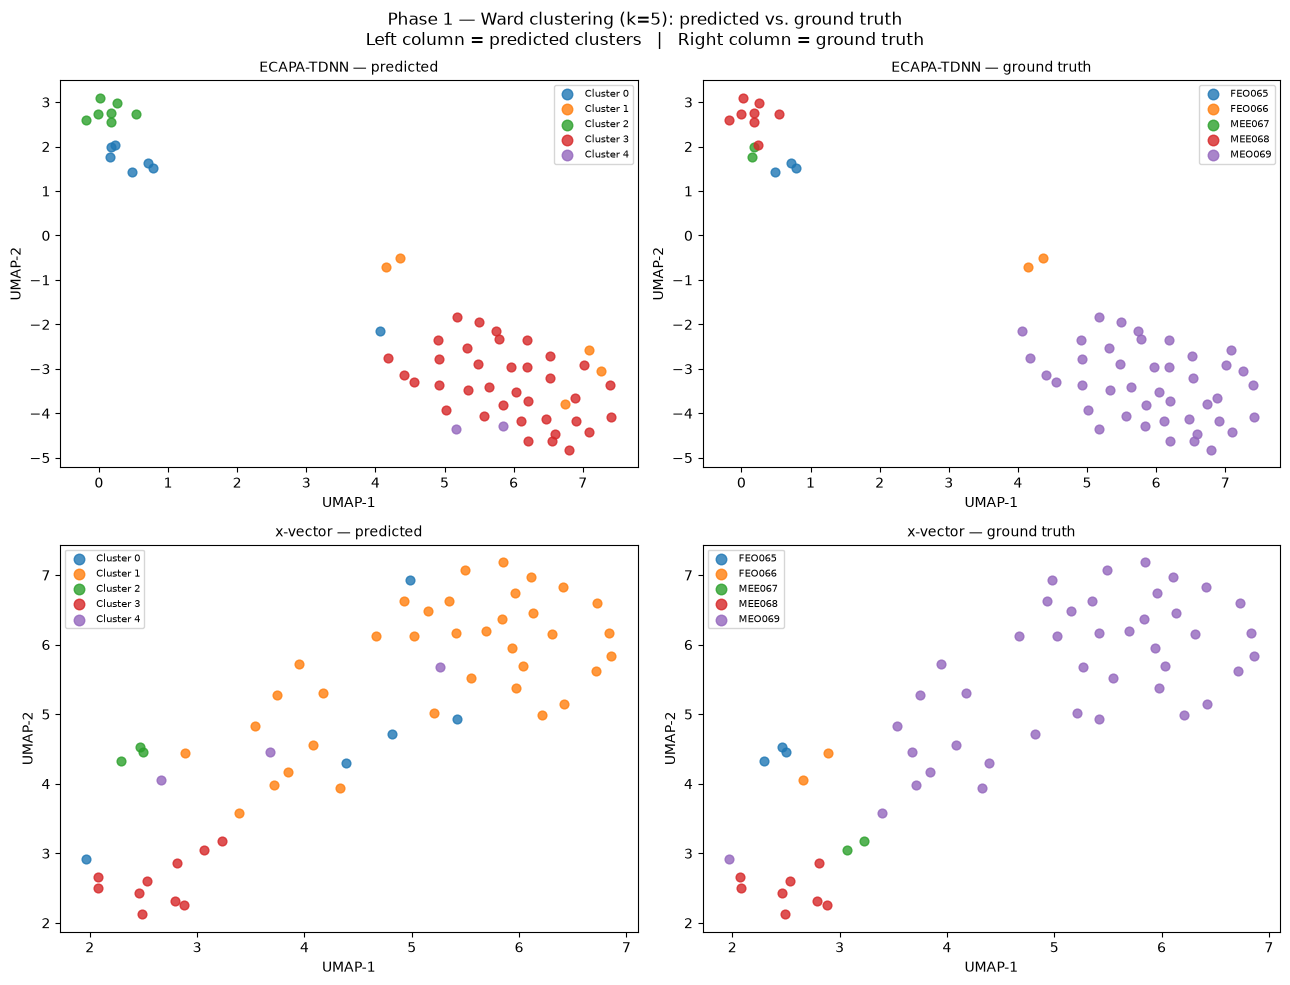

Saved → output/clustering/phase1_umap.png


In [15]:
# ── Phase 1 UMAP: predicted clusters vs ground truth, both embeddings ─────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Phase 1 — Ward clustering (k=5): predicted vs. ground truth\n"
             "Left column = predicted clusters   |   Right column = ground truth",
             fontsize=12)

datasets = [
    (umap_ecapa, pred_ecapa_p1, "ECAPA-TDNN"),
    (umap_xvect, pred_xvect_p1, "x-vector"),
]

for row, (umap_2d, pred, name) in enumerate(datasets):
    # --- predicted clusters (left) ---
    ax = axes[row][0]
    ax.set_title(f"{name} — predicted", fontsize=10)
    for c in range(N_SPEAKERS_KNOWN):
        mask = pred == c
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
                   color=cluster_pal[c], s=40, alpha=0.8, label=f"Cluster {c}")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2)

    # --- ground truth (right) ---
    ax = axes[row][1]
    ax.set_title(f"{name} — ground truth", fontsize=10)
    for spk in speakers:
        mask = np.array(gt_labels) == spk
        ax.scatter(umap_2d[mask, 0], umap_2d[mask, 1],
                   color=gt_palette[spk], s=40, alpha=0.8, label=spk)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.2)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "phase1_umap.png", dpi=120)
plt.show()
print("Saved → output/clustering/phase1_umap.png")


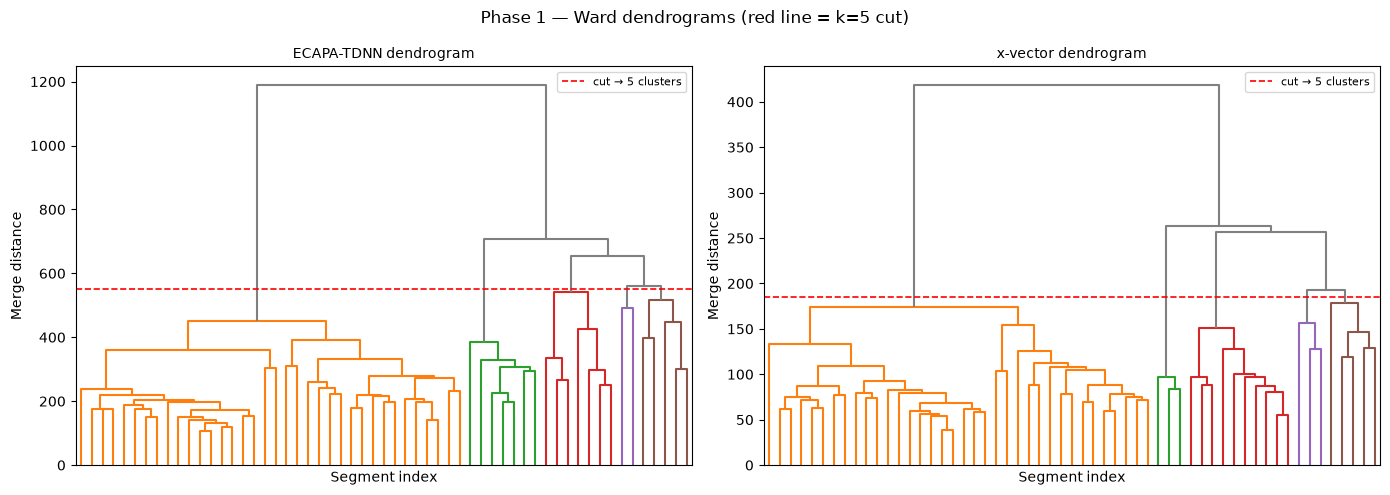

Saved → output/clustering/phase1_dendrogram.png

Interpretation: ECAPA's dendrogram should show a clear gap before the k=5
cut (large merge distances between clusters). x-vector's dendrogram will
show uniformly small gaps — consistent with its poor separation score.


In [16]:
# ── Phase 1 dendrograms ────────────────────────────────────────────────────────
# We use scipy's complete linkage on L2-normalised embeddings to approximate
# cosine-distance agglomeration for a faithful dendrogram view.
# (Ward on raw embeddings ≈ this when embeddings are normalised.)

def make_dendrogram(embs, title, ax, n_keep=5):
    """
    Draw a dendrogram on `ax` using Ward/Euclidean linkage.
    The horizontal dashed line marks the cut that produces n_keep clusters.
    """
    Z = linkage(embs, method="ward", metric="euclidean")
    cut_h = (Z[-(n_keep), 2] + Z[-(n_keep - 1), 2]) / 2
    dendrogram(Z, ax=ax, no_labels=True,
               color_threshold=cut_h,
               above_threshold_color="grey",
               link_color_func=None)
    ax.axhline(cut_h, color="red", linestyle="--", linewidth=1.2,
               label=f"cut → {n_keep} clusters")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Segment index")
    ax.set_ylabel("Merge distance")
    ax.legend(fontsize=8)
    return Z


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Phase 1 — Ward dendrograms (red line = k=5 cut)", fontsize=12)
Z_ecapa = make_dendrogram(embs_ecapa, "ECAPA-TDNN dendrogram", ax1, N_SPEAKERS_KNOWN)
Z_xvect = make_dendrogram(embs_xvect, "x-vector dendrogram",   ax2, N_SPEAKERS_KNOWN)
plt.tight_layout()
plt.savefig(CLUSTER_OUT / "phase1_dendrogram.png", dpi=120)
plt.show()
print("Saved → output/clustering/phase1_dendrogram.png")
print()
print("Interpretation: ECAPA's dendrogram should show a clear gap before the k=5")
print("cut (large merge distances between clusters). x-vector's dendrogram will")
print("show uniformly small gaps — consistent with its poor separation score.")


### Phase 1 — Conclusion

**ECAPA-TDNN wins**.

The silhouette and ARI scores confirm what the embedding-space analysis already
hinted at (notebook 02): ECAPA-TDNN (192-d) separates speakers far better than
x-vector (512-d) for this meeting.

Why? x-vector embeddings produced a separation gap of only 0.04 (vs. 0.51 for
ECAPA), meaning all segment embeddings are crammed into a small region of the
512-dimensional space — ward clustering partitions noise there, not genuine speaker
boundaries.

**ECAPA-TDNN carries forward to Phase 2.**


---
## Phase 2 — Which Clustering Algorithm Is Better?

**Protocol**: hold the embedding fixed (ECAPA-TDNN), vary the clustering algorithm.

We compare three common approaches:

| Algorithm | Key property |
|-----------|-------------|
| Agglomerative + **ward** | minimises within-cluster variance (Euclidean) |
| Agglomerative + **average / cosine** | builds on cosine distances — natural for speaker embeddings |
| **Spectral** (precomputed cosine affinity) | graph-based, handles non-convex clusters |

All runs use k = 5.  Silhouette is computed with cosine distance throughout
so the scores are comparable across methods.


In [17]:
def cluster_average_cosine(embs, n_clusters):
    """Agglomerative clustering — average linkage with cosine metric."""
    clf = AgglomerativeClustering(n_clusters=n_clusters,
                                  linkage="average",
                                  metric="cosine")
    return clf.fit_predict(embs)


def cluster_spectral_cosine(embs, n_clusters):
    """
    Spectral clustering on a precomputed cosine affinity matrix.

    Raw cosine similarity lies in [-1, 1]; we remap to [0, 1] so the
    affinity matrix is non-negative (required by SpectralClustering).
    """
    affinity = (cosine_similarity(embs) + 1.0) / 2.0
    np.fill_diagonal(affinity, 1.0)
    clf = SpectralClustering(n_clusters=n_clusters,
                             affinity="precomputed",
                             assign_labels="kmeans",
                             random_state=42)
    return clf.fit_predict(affinity)


# ── Run Phase 2 ───────────────────────────────────────────────────────────────
algorithms = [
    ("Ward (Euclidean)",         cluster_ward,           "ward"),
    ("Average (cosine)",         cluster_average_cosine, "avg_cos"),
    ("Spectral (cosine kernel)", cluster_spectral_cosine, "spectral"),
]

p2_results = {}
rows_p2    = []

for name, fn, key in algorithms:
    preds = fn(embs_ecapa, N_SPEAKERS_KNOWN)
    sil, ari = eval_clustering(embs_ecapa, preds, gt_ints)
    p2_results[key] = preds
    rows_p2.append({"Algorithm": name,
                    "Silhouette ↑": f"{sil:.4f}",
                    "ARI ↑":        f"{ari:.4f}"})
    print(f"  {name:30s}  sil={sil:.4f}  ari={ari:.4f}")

print()
df_p2 = pd.DataFrame(rows_p2).set_index("Algorithm")

# Mark the overall winner by silhouette
sil_vals = [float(r["Silhouette ↑"]) for r in rows_p2]
best_idx = int(np.argmax(sil_vals))
df_p2["Winner"] = ""
df_p2.iloc[best_idx, df_p2.columns.get_loc("Winner")] = "✓"

print("Phase 2 — ECAPA-TDNN embeddings, k=5, varying algorithm")
print("=" * 62)
print(df_p2.to_string())
print()
best_algo_key   = algorithms[best_idx][2]
best_algo_name  = algorithms[best_idx][0]
best_algo_preds = p2_results[best_algo_key]
print(f"→ Phase 2 winner: {best_algo_name}")


  Ward (Euclidean)                sil=0.4083  ari=0.6834
  Average (cosine)                sil=0.4565  ari=0.9278
  Spectral (cosine kernel)        sil=0.2461  ari=0.4495

Phase 2 — ECAPA-TDNN embeddings, k=5, varying algorithm
                         Silhouette ↑   ARI ↑ Winner
Algorithm                                           
Ward (Euclidean)               0.4083  0.6834       
Average (cosine)               0.4565  0.9278      ✓
Spectral (cosine kernel)       0.2461  0.4495       

→ Phase 2 winner: Average (cosine)


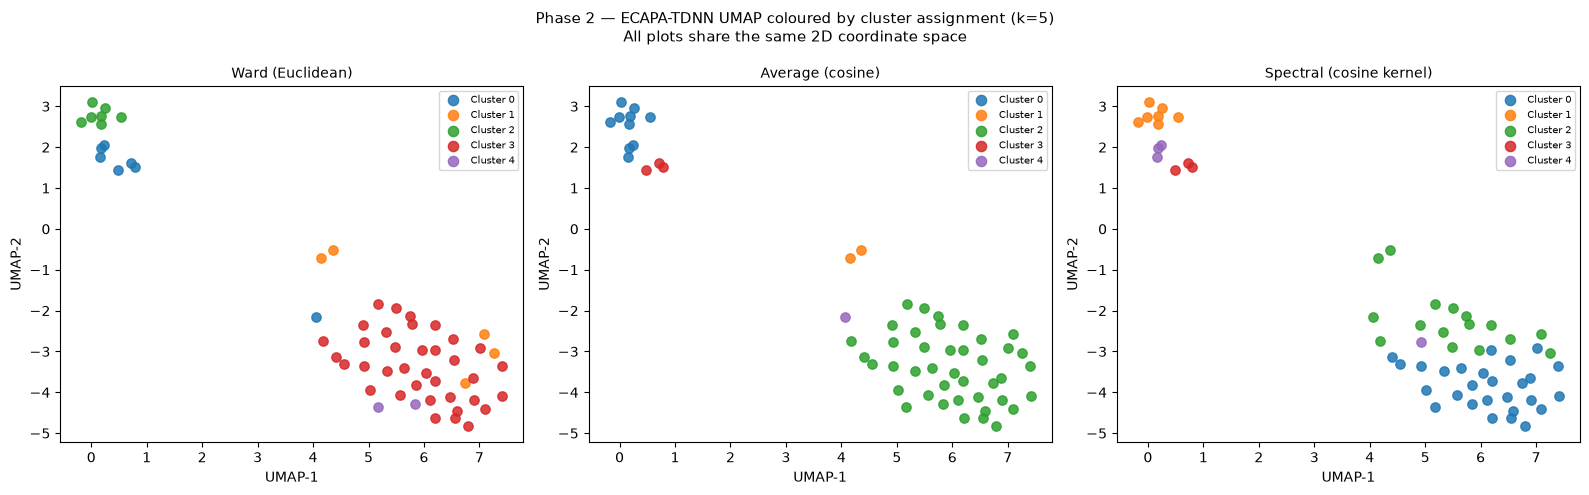

Saved → output/clustering/phase2_umap.png


In [18]:
# ── Phase 2 UMAP: three algorithms on the same ECAPA projection ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Phase 2 — ECAPA-TDNN UMAP coloured by cluster assignment (k=5)\n"
             "All plots share the same 2D coordinate space", fontsize=11)

algo_keys  = [("Ward (Euclidean)",         "ward"),
              ("Average (cosine)",         "avg_cos"),
              ("Spectral (cosine kernel)", "spectral")]

for ax, (alg_name, key) in zip(axes, algo_keys):
    preds = p2_results[key]
    for c in range(N_SPEAKERS_KNOWN):
        mask = preds == c
        ax.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                   color=cluster_pal[c], s=45, alpha=0.85, label=f"Cluster {c}")
    ax.set_title(alg_name, fontsize=10)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.legend(fontsize=7, markerscale=1.1)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "phase2_umap.png", dpi=120)
plt.show()
print("Saved → output/clustering/phase2_umap.png")


---
## Step 4 — How Many Clusters Are There?

We already know there are 5 speakers, but in a real scenario k would be unknown.
This section uses two complementary tools to validate (or challenge) k = 5:

1. **Dendrogram merge-height analysis** — the gap between successive merge heights
   just before the cut point signals natural cluster count.
2. **Silhouette vs. k curve** — sweep k from 2 to 8 and plot silhouette.
   The curve should show an elbow or peak near k = 5.

Note: with EN2001a's heavy imbalance (MEO069 = 74 % of segments) the silhouette
curve may actually peak at k = 2 (one big cluster vs. everything else).
Both outcomes are informative and reported below.


  k=2  silhouette=0.4169
  k=3  silhouette=0.4354
  k=4  silhouette=0.4199
  k=5  silhouette=0.4083
  k=6  silhouette=0.4262
  k=7  silhouette=0.4031
  k=8  silhouette=0.3885

Peak silhouette at k=3   (ground truth: k=5)

Top merge distances (ECAPA, Ward):
  k=3→2  height=1188.3491
  k=4→3  height=708.4868
  k=5→4  height=653.6455
  k=6→5  height=560.1678 ← suggested cut
  k=7→6  height=540.7909
  k=8→7  height=515.3066
  k=9→8  height=492.3351
  k=10→9  height=449.6400


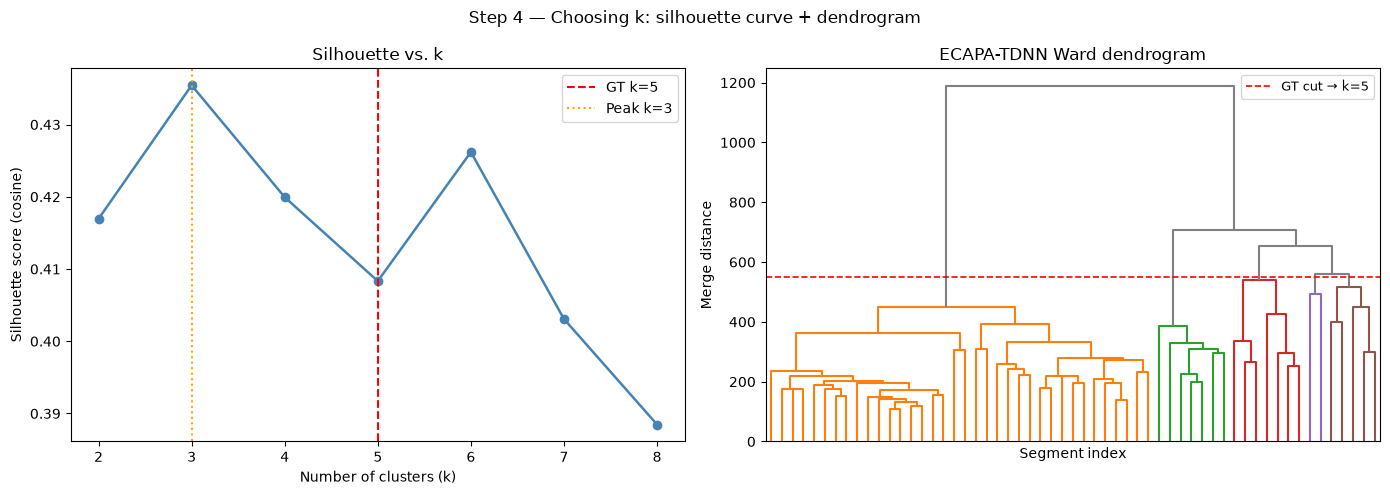

Saved → output/clustering/n_clusters_analysis.png


In [19]:
# ── Silhouette vs k ───────────────────────────────────────────────────────────
K_MIN, K_MAX = 2, 8
k_range = list(range(K_MIN, K_MAX + 1))
sil_per_k = []
for k in k_range:
    preds_k = cluster_ward(embs_ecapa, k)
    s = silhouette_score(embs_ecapa, preds_k, metric="cosine")
    sil_per_k.append(s)
    print(f"  k={k}  silhouette={s:.4f}")

sil_peak_k = k_range[int(np.argmax(sil_per_k))]
print(f"\nPeak silhouette at k={sil_peak_k}   (ground truth: k={N_SPEAKERS_KNOWN})")

# ── Dendrogram cut-height analysis ────────────────────────────────────────────
Z_e = linkage(embs_ecapa, method="ward", metric="euclidean")
# merge heights for the final N merges (top of the tree)
last_merges = Z_e[-(K_MAX):, 2][::-1]   # index 0 = largest merge distance
print("\nTop merge distances (ECAPA, Ward):")
for i, h in enumerate(last_merges, start=2):
    marker = " ← suggested cut" if i == N_SPEAKERS_KNOWN else ""
    print(f"  k={i+1}→{i}  height={h:.4f}{marker}")

cut_h_gt = (Z_e[-N_SPEAKERS_KNOWN, 2] + Z_e[-(N_SPEAKERS_KNOWN - 1), 2]) / 2

# ── Combined figure ───────────────────────────────────────────────────────────
fig, (ax_sil, ax_dend) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Step 4 — Choosing k: silhouette curve + dendrogram", fontsize=12)

# Silhouette curve
ax_sil.plot(k_range, sil_per_k, "o-", linewidth=1.8, color="steelblue")
ax_sil.axvline(N_SPEAKERS_KNOWN, color="red",    linestyle="--", label=f"GT k={N_SPEAKERS_KNOWN}")
ax_sil.axvline(sil_peak_k,       color="orange", linestyle=":",  label=f"Peak k={sil_peak_k}")
ax_sil.set_xlabel("Number of clusters (k)")
ax_sil.set_ylabel("Silhouette score (cosine)")
ax_sil.set_title("Silhouette vs. k")
ax_sil.set_xticks(k_range)
ax_sil.legend()

# Dendrogram
dendrogram(Z_e, ax=ax_dend, no_labels=True,
           color_threshold=cut_h_gt,
           above_threshold_color="grey")
ax_dend.axhline(cut_h_gt, color="red", linestyle="--", linewidth=1.2,
                label=f"GT cut → k={N_SPEAKERS_KNOWN}")
ax_dend.set_title("ECAPA-TDNN Ward dendrogram")
ax_dend.set_xlabel("Segment index")
ax_dend.set_ylabel("Merge distance")
ax_dend.legend(fontsize=9)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "n_clusters_analysis.png", dpi=120)
plt.show()
print("Saved → output/clustering/n_clusters_analysis.png")


---
## Step 5 — Final: Best Combination + Label Assignment

We now apply the winning combination from both phases:

* **Embedding** : ECAPA-TDNN (Phase 1 winner)
* **Algorithm** : determined by Phase 2 silhouette result (variable `best_algo_preds`)
* **k = 5**      : from ground-truth metadata

Cluster IDs (0-4) are anonymous — the model has no access to ground-truth names.
The output keeps them as `cluster_0 … cluster_4`.  The evaluation notebook (06)
will solve the optimal assignment to named speakers via the Hungarian algorithm.

Below we show a final side-by-side UMAP: left = predicted clusters, right = GT speakers.


Final combination : ECAPA-TDNN + Average (cosine)
  Silhouette (cosine) : 0.4565
  ARI vs GT           : 0.9278

Predicted cluster sizes:
  cluster_0: 10 segments
  cluster_1: 2 segments
  cluster_2: 41 segments
  cluster_3: 3 segments
  cluster_4: 1 segments


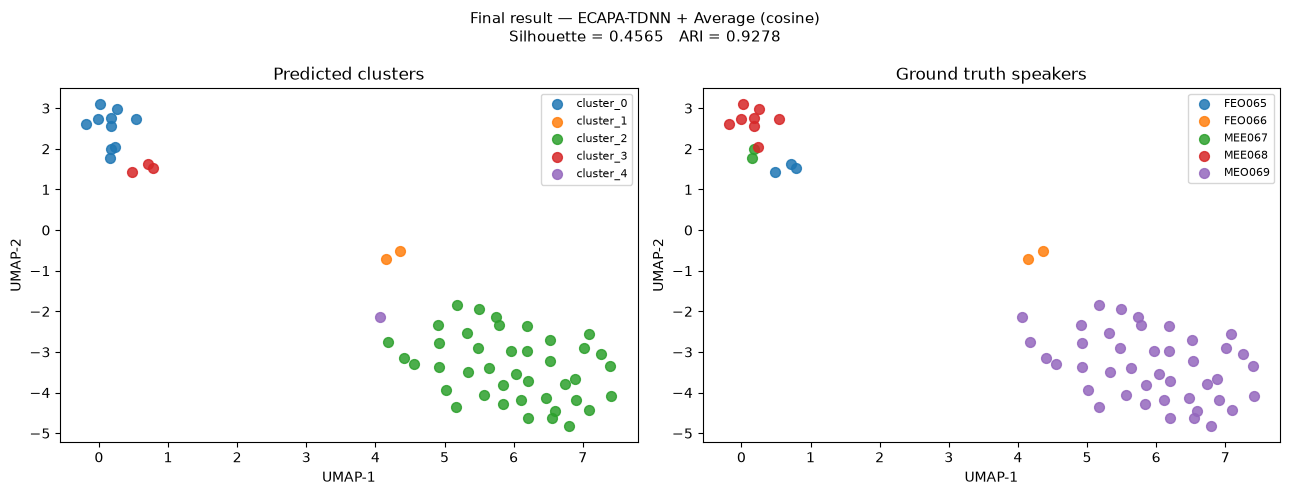

Saved → output/clustering/final_result.png


In [20]:
# ── Final predicted labels ────────────────────────────────────────────────────
final_labels = best_algo_preds  # already computed above
final_sil, final_ari = eval_clustering(embs_ecapa, final_labels, gt_ints)

print(f"Final combination : ECAPA-TDNN + {best_algo_name}")
print(f"  Silhouette (cosine) : {final_sil:.4f}")
print(f"  ARI vs GT           : {final_ari:.4f}")
print()
print("Predicted cluster sizes:")
for c, cnt in sorted(Counter(final_labels.tolist()).items()):
    print(f"  cluster_{c}: {cnt} segments")

# ── Final UMAP ────────────────────────────────────────────────────────────────
fig, (ax_pred, ax_gt) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Final result — ECAPA-TDNN + {best_algo_name}\n"
             f"Silhouette = {final_sil:.4f}   ARI = {final_ari:.4f}", fontsize=11)

# Predicted
for c in range(N_SPEAKERS_KNOWN):
    mask = final_labels == c
    ax_pred.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                    color=cluster_pal[c], s=50, alpha=0.85, label=f"cluster_{c}")
ax_pred.set_title("Predicted clusters")
ax_pred.set_xlabel("UMAP-1")
ax_pred.set_ylabel("UMAP-2")
ax_pred.legend(fontsize=8)

# Ground truth
for spk in speakers:
    mask = np.array(gt_labels) == spk
    ax_gt.scatter(umap_ecapa[mask, 0], umap_ecapa[mask, 1],
                  color=gt_palette[spk], s=50, alpha=0.85, label=spk)
ax_gt.set_title("Ground truth speakers")
ax_gt.set_xlabel("UMAP-1")
ax_gt.set_ylabel("UMAP-2")
ax_gt.legend(fontsize=8)

plt.tight_layout()
plt.savefig(CLUSTER_OUT / "final_result.png", dpi=120)
plt.show()
print("Saved → output/clustering/final_result.png")


---
## Step 6 — Save Results

Output file: `output/clustering/segments_labeled.json`

Schema:
```json
{
  "meeting_id": "EN2001a",
  "model":      "ecapa-tdnn",
  "algorithm":  "<winner>",
  "n_clusters": 5,
  "silhouette": 0.xxxx,
  "ari":        0.xxxx,
  "segments": [
    { "seg_id": 0, "start": 0.0, "end": 2.3, "duration": 2.3, "speaker_label": "cluster_2" },
    ...
  ]
}
```

`speaker_label` values are `cluster_0 … cluster_4`.
Notebook 05 (integration) reads this file to join speaker labels with ASR transcripts.


In [21]:
output_segments = []
for i, (info, label) in enumerate(zip(seg_info, final_labels.tolist())):
    output_segments.append({
        "seg_id":       info["seg_id"],
        "start":        info["start"],
        "end":          info["end"],
        "duration":     info["duration"],
        "speaker_label": f"cluster_{label}",
    })

result = {
    "meeting_id": "EN2001a",
    "model":      "ecapa-tdnn",
    "algorithm":  best_algo_name,
    "n_clusters": N_SPEAKERS_KNOWN,
    "silhouette": round(float(final_sil), 6),
    "ari":        round(float(final_ari), 6),
    "segments":   output_segments,
}

out_path = CLUSTER_OUT / "segments_labeled.json"
with open(out_path, "w") as fh:
    json.dump(result, fh, indent=2)

print(f"Saved {len(output_segments)} segments → {out_path}")
print()
print("Summary:")
print(f"  Meeting     : {result['meeting_id']}")
print(f"  Embedding   : {result['model']}")
print(f"  Algorithm   : {result['algorithm']}")
print(f"  k           : {result['n_clusters']}")
print(f"  Silhouette  : {result['silhouette']}")
print(f"  ARI         : {result['ari']}")
print()
print("Pipeline stage complete.  Next: notebook 04 (ASR with Whisper).")


Saved 57 segments → output/clustering/segments_labeled.json

Summary:
  Meeting     : EN2001a
  Embedding   : ecapa-tdnn
  Algorithm   : Average (cosine)
  k           : 5
  Silhouette  : 0.456459
  ARI         : 0.927799

Pipeline stage complete.  Next: notebook 04 (ASR with Whisper).
